# **TEAM ANALYSIS**

In [ ]:
from google.colab import drive
import pandas as pd
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Mount the Drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/IPL_PROJECT/IPL_match_level.csv'
df = pd.read_csv(file_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Team Win Percentage**

## Question: Which teams are most successful?

In [ ]:
team_wins = df['winner'].value_counts()

team_matches = pd.concat([
   df['bat_first_team'],
    df['chasing_team']
]).value_counts()

team_win_pct = (team_wins / team_matches) * 100

team_win_pct = team_win_pct.sort_values(ascending=False)

team_win_pct.head(10)

,count
GT,61.666667
CSK,56.800000
MI,55.311355
LSG,52.631579
KKR,52.123552
RPS,50.000000
RCB,50.000000
RR,49.781659
PBKS,46.124031
SRH,45.864662


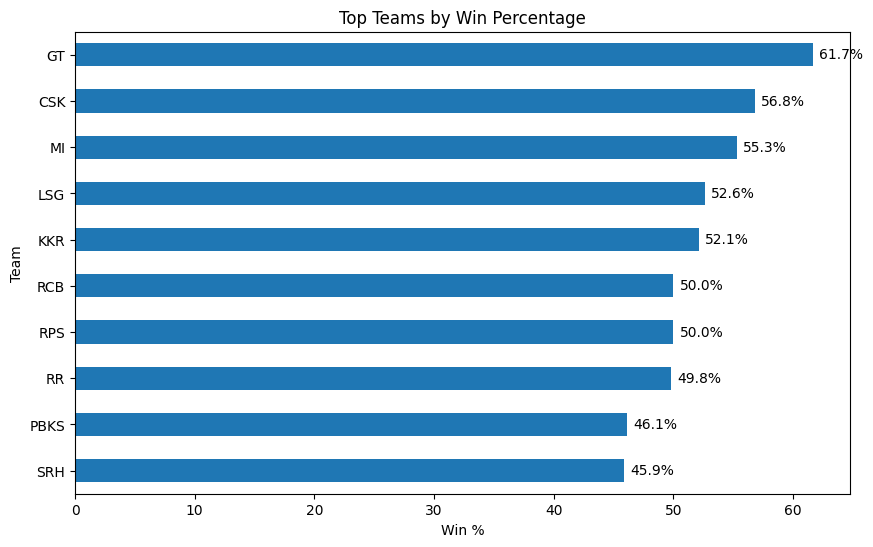

In [ ]:
import matplotlib.pyplot as plt

ax = team_win_pct.head(10).sort_values().plot(kind='barh', figsize=(10,6))

# Add labels
for i, v in enumerate(team_win_pct.head(10).sort_values()):
    ax.text(v + 0.5, i, f"{v:.1f}%", va='center')

plt.title('Top Teams by Win Percentage')
plt.xlabel('Win %')
plt.ylabel('Team')

plt.show()

### Insight: Certain teams consistently maintain higher win percentages, indicating stronger overall performance and better adaptability across match situations

# **BAT VS CHASE PERFORMANCE(TEAM LEVEL)**

## Question: Which teams perform better while chasing vs defending?

In [ ]:
# CREATE PERFORMACE FLAGS
team_analysis = df.copy()

team_analysis['bat_first_win'] = team_analysis['winner'] == team_analysis['bat_first_team']
team_analysis['chase_win'] = team_analysis['winner'] == team_analysis['chasing_team']

In [ ]:
# CALCULATING WIN%
bat_first_perf = team_analysis.groupby('bat_first_team')['bat_first_win'].mean() * 100
chase_perf = team_analysis.groupby('chasing_team')['chase_win'].mean() * 100

In [ ]:
# COMBINE
bat_first_perf = bat_first_perf.rename('bat_first_win_pct')
chase_perf = chase_perf.rename('chase_win_pct')

team_style = pd.concat([bat_first_perf, chase_perf], axis=1)
# Add match count filter
team_matches = pd.concat([
    df['bat_first_team'],
    df['chasing_team']
]).value_counts()

valid_teams = team_matches[team_matches >= 20].index

team_style = team_style.loc[team_style.index.isin(valid_teams)]

In [ ]:
team_style['difference'] = team_style['chase_win_pct'] - team_style['bat_first_win_pct']

team_style.sort_values(by='difference', ascending=False).head(10)

,bat_first_win_pct,chase_win_pct,difference
GL,7.692308,75.000000,67.307692
RPS,33.333333,66.666667,33.333333
KKR,44.354839,59.259259,14.904421
PBKS,40.441176,52.459016,12.017840
RR,43.269231,55.200000,11.930769
GT,55.555556,66.666667,11.111111
CSK,52.205882,62.280702,10.074819
RCB,46.268657,53.846154,7.577497
DC,41.964286,48.630137,6.665851
MI,53.900709,56.818182,2.917473


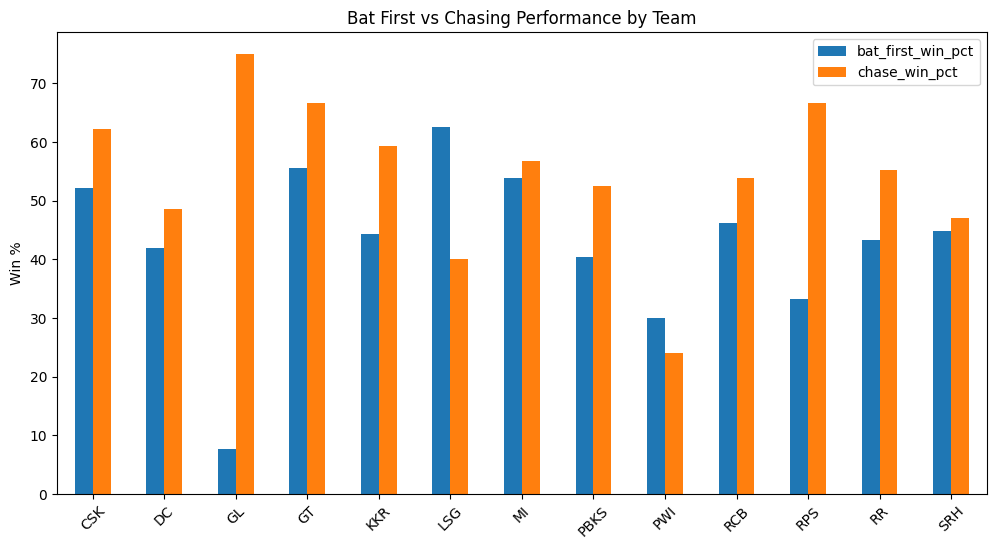

In [ ]:
team_style[['bat_first_win_pct', 'chase_win_pct']].plot(
    kind='bar', figsize=(12,6)
)

plt.title('Bat First vs Chasing Performance by Team')
plt.ylabel('Win %')

plt.xticks(rotation=45)
plt.show()

## Interpretation:

## difference > 0 → team better at chasing

## difference < 0 → team better at defending

### Insight: The variation between batting-first and chasing win percentages highlights that teams are not universally adaptable, but instead rely on specific strengths. After filtering out teams with limited matches, this pattern becomes more reliable, showing that strategic preferences play a key role in team success.

# **Toss Strategy by Team**

In [ ]:
toss_pref = df.groupby(['toss_winner', 'toss_decision']).size().unstack()

toss_pref

toss_decision,bat,field
toss_winner,,
CSK,60.0,66.0
DC,40.0,95.0
GL,NaN,14.0
GT,6.0,23.0
KKR,40.0,87.0
KTK,3.0,5.0
LSG,7.0,17.0
MI,52.0,96.0
PBKS,36.0,82.0


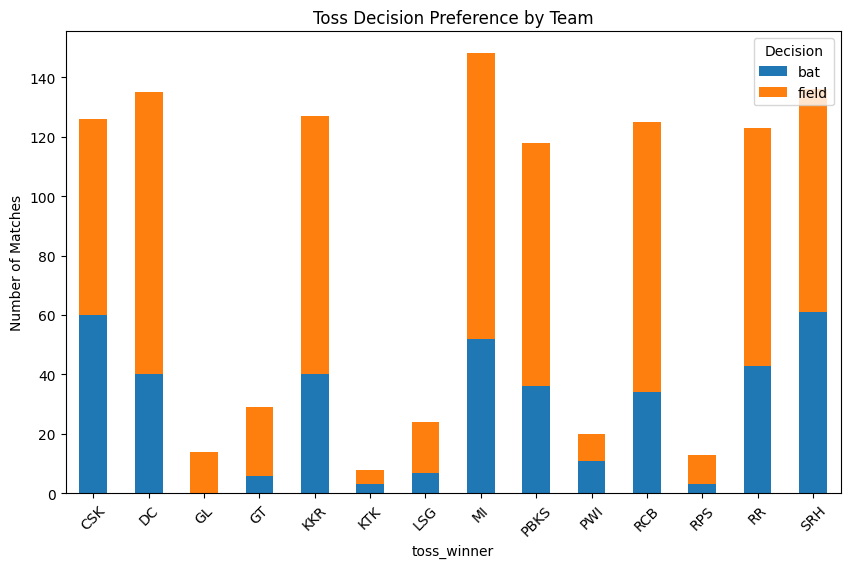

In [ ]:
toss_pref.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title('Toss Decision Preference by Team')
plt.ylabel('Number of Matches')

plt.xticks(rotation=45)
plt.legend(title='Decision')
plt.show()

### Insight: Teams show clear preferences in toss decisions, with many opting to field first, reflecting the general advantage of chasing in T20 cricket

# **VENUE DOMINANCE**

### Question: Which teams truly dominate specific venues?

In [ ]:
# Combine both teams
teams_venue = pd.concat([
    df[['venue', 'bat_first_team']].rename(columns={'bat_first_team': 'team'}),
    df[['venue', 'chasing_team']].rename(columns={'chasing_team': 'team'})
])

# Matches played
venue_matches = teams_venue.groupby(['venue', 'team']).size().reset_index(name='matches')

# Wins
venue_wins = df.groupby(['venue', 'winner']).size().reset_index(name='wins')
venue_wins = venue_wins.rename(columns={'winner': 'team'})

# Merge
venue_stats = venue_matches.merge(venue_wins, on=['venue', 'team'], how='left')
venue_stats['wins'] = venue_stats['wins'].fillna(0)

# Win %
venue_stats['win_pct'] = (venue_stats['wins'] / venue_stats['matches']) * 100

# ✅ Filter meaningful data
venue_stats = venue_stats[venue_stats['matches'] >= 10]

# Sort
venue_stats.sort_values(by='win_pct', ascending=False).head(15)

,venue,team,matches,wins,win_pct
81,"Eden Gardens, Kolkata",MI,14,10.0,71.428571
152,"M Chinnaswamy Stadium, Bengaluru",MI,13,9.0,69.230769
159,"MA Chidambaram Stadium, Chennai",CSK,76,51.0,67.105263
9,"Arun Jaitley Stadium, Delhi",CSK,12,8.0,66.666667
277,"Sheikh Zayed Stadium, Abu Dhabi",MI,12,8.0,66.666667
149,"M Chinnaswamy Stadium, Bengaluru",KKR,15,10.0,66.666667
22,"Arun Jaitley Stadium, Delhi",SRH,17,11.0,64.705882
66,"Dubai International Stadium, UAE",CSK,14,9.0,64.285714
240,"Rajiv Gandhi International Stadium, Hyderabad",MI,14,9.0,64.285714
71,"Dubai International Stadium, UAE",RCB,11,7.0,63.636364


### Insight: By focusing on win percentage and filtering out teams with limited matches, the analysis reveals true venue dominance rather than misleading totals driven by match frequency. This highlights how certain teams leverage familiarity with pitch conditions and ground dimensions to maintain a competitive edge at specific venues

# **Team analysis summary**

### Insight: Team-level analysis reveals that consistent success in IPL is driven by strategic adaptability and situational strengths. While some teams excel in chasing scenarios, others perform better when defending totals, highlighting distinct tactical preferences. Additionally, venue-based win percentage analysis, adjusted for match frequency, uncovers true home-ground advantages. Overall, successful teams combine strategic clarity, adaptability, and effective utilization of conditions.